# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus

In [2]:
corpus = [
    "The journey to Mars represents humanity's next great leap.",
    "Rockets must overcome Earth's gravity to reach deep space.",
    "Astronauts train for years to prepare for the harsh environment.",
    "Future colonies will require sustainable life support systems.",
    "Exploring the cosmos expands our understanding of the universe.",
    "Beyond Mars, the icy moons of Jupiter and Saturn offer tantalizing clues about extraterrestrial life.",
    "Europa, with its vast subsurface ocean, is a prime target for robotic submarines.",
    "Interstellar travel remains a distant dream, limited by the massive distances between star systems.",
    "However, theoretical concepts like warp drives and wormholes continue to inspire physicists.",
    "Telescopes peer back to the dawn of time, revealing the formation of the first early galaxies.",
    "Every new astronomical discovery reminds us of how much we have yet to learn.",
    "The relentless spirit of exploration is hardwired deeply into our human DNA.",
    "As we reach for the distant stars, we carry the collective hopes and dreams of all mankind.",
    "In the absolute silence of the void, our tiny spacecraft are a testament to human ingenuity.",
    "The final cosmic frontier beckons, continuously challenging us to push beyond our limits."
]
print(corpus)

["The journey to Mars represents humanity's next great leap.", "Rockets must overcome Earth's gravity to reach deep space.", 'Astronauts train for years to prepare for the harsh environment.', 'Future colonies will require sustainable life support systems.', 'Exploring the cosmos expands our understanding of the universe.', 'Beyond Mars, the icy moons of Jupiter and Saturn offer tantalizing clues about extraterrestrial life.', 'Europa, with its vast subsurface ocean, is a prime target for robotic submarines.', 'Interstellar travel remains a distant dream, limited by the massive distances between star systems.', 'However, theoretical concepts like warp drives and wormholes continue to inspire physicists.', 'Telescopes peer back to the dawn of time, revealing the formation of the first early galaxies.', 'Every new astronomical discovery reminds us of how much we have yet to learn.', 'The relentless spirit of exploration is hardwired deeply into our human DNA.', 'As we reach for the dista

# 🔤 Tokenization & Sequence Creation

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

X = input_sequences[:,:-1]
y = input_sequences[:,-1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 139
X shape: (172, 16)
y shape: (172, 139)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 50, input_length=max_sequence_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 50, input_length=max_sequence_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 50, input_length=max_sequence_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

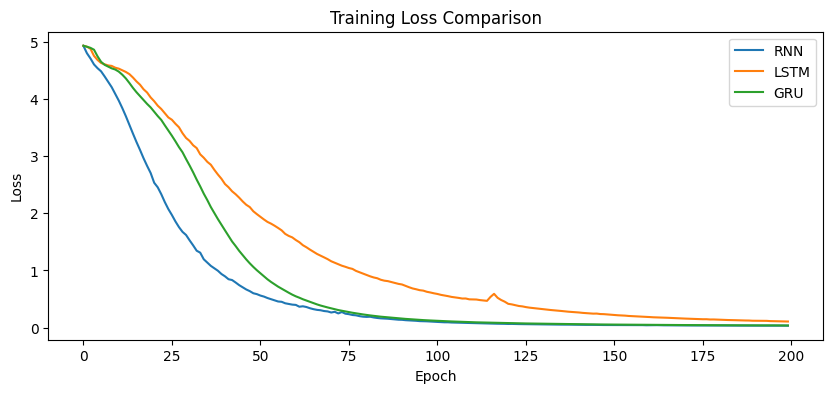

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text

In [9]:
print("RNN :", generate_text(rnn_model, "Europa, with its", 10))
print("LSTM:", generate_text(lstm_model, "Interstellar travel remains a", 10))
print("GRU :", generate_text(gru_model, "Beyond Mars, the icy moons", 10))

RNN : Europa, with its vast subsurface ocean is a prime target for robotic submarines
LSTM: Interstellar travel remains a distant dream limited by the massive distances between star systems
GRU : Beyond Mars, the icy moons of jupiter and saturn offer tantalizing clues about extraterrestrial life
